### Задание

Создайте систему компьютерного зрения, которая будет определять тип геометрической фигуры. Используя подготовленную базу и шаблон ноутбука проведите серию экспериментов по перебору гиперпараметров нейронной сети, распознающей три категории изображений (треугольник, круг, квадрат).

1. Поменяйте количество нейронов в сети, используя следующие значения:

- один слой 10 нейронов
- один слой 100 нейронов
- один слой 5000 нейронов.

2. Поменяйте активационную функцию в скрытых слоях с `relu` на `linear`.
3. Поменяйте размеры batch_size:
- 10
- 100
- 1000

4. Выведите на экран получившиеся точности.

Всего должно получиться 18 комбинаций указанных параметров.

Создайте сравнительную таблицу по результатам проведенных тестов.

In [16]:
# Подключение библиотек
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Для обработки изображений
from torchvision import transforms
from PIL import Image

# Для отрисовки
%matplotlib inline

In [17]:
import gdown
url = 'https://drive.google.com/uc?id=1yt_hr4AYEWbjtmYfTNSlEkxl5JaFuYEX'
gdown.download(url, 'hw_light.zip', quiet=False)
!unzip -o -q hw_light.zip

print("Данные загружены")

Downloading...
From: https://drive.google.com/uc?id=1yt_hr4AYEWbjtmYfTNSlEkxl5JaFuYEX
To: /content/hw_light.zip
100%|██████████| 304k/304k [00:00<00:00, 83.7MB/s]

Данные загружены


In [18]:
base_dir = '/content/hw_light'
x_train, y_train = [], []
img_height, img_width = 20, 20

print("Загрузка изображений...")
for patch in os.listdir(base_dir):
    patch_path = os.path.join(base_dir, patch)
    if os.path.isdir(patch_path):
        for img_file in os.listdir(patch_path):
            img_path = os.path.join(patch_path, img_file)
            img = Image.open(img_path).convert('L')
            img = img.resize((img_height, img_width))
            img_array = np.array(img).astype('float32')
            x_train.append(img_array)

            if patch == '0':
                y_train.append(0)
            elif patch == '3':
                y_train.append(1)
            else:
                y_train.append(2)

x_train = np.array(x_train)
y_train = np.array(y_train)

print(f'Изображений: {x_train.shape}')
print(f'Меток: {y_train.shape}')

Загрузка изображений...
Изображений: (302, 20, 20)
Меток: (302,)


In [19]:
CLASS_COUNT = 3

x_train = x_train.reshape(x_train.shape[0], -1)
print(f'После reshape: {x_train.shape}')

x_train = x_train / 255.0
print(f'Нормализация: [{x_train.min():.2f}, {x_train.max():.2f}]')

x_tensor = torch.FloatTensor(x_train)
y_tensor = torch.LongTensor(y_train)

print(f'Тензоры: x {x_tensor.shape}, y {y_tensor.shape}')

После reshape: (302, 400)
Нормализация: [0.00, 1.00]
Тензоры: x torch.Size([302, 400]), y torch.Size([302])


In [20]:
np.random.seed(42)
indices = np.random.permutation(len(x_train))
x_tensor = x_tensor[indices]
y_tensor = y_tensor[indices]

val_size = int(0.2 * len(x_tensor))

x_train_split = x_tensor[val_size:]
y_train_split = y_tensor[val_size:]

x_val = x_tensor[:val_size]
y_val = y_tensor[:val_size]

print(f'Обучающая: {x_train_split.shape}')
print(f'Валидационная: {x_val.shape}')

Обучающая: torch.Size([242, 400])
Валидационная: torch.Size([60, 400])


In [21]:
class OneLayerNN(nn.Module):
    def __init__(self, input_dim=400, hidden_neurons=10, activation='relu', num_classes=3):
        super(OneLayerNN, self).__init__()

        if activation == 'relu':
            self.activation = nn.ReLU()
        else:
            self.activation = nn.Identity()

        self.hidden = nn.Linear(input_dim, hidden_neurons)
        self.output = nn.Linear(hidden_neurons, num_classes)

    def forward(self, x):
        x = self.hidden(x)
        x = self.activation(x)
        x = self.output(x)
        return x

In [22]:
def train_and_evaluate_pytorch(neurons, activation, batch_size, epochs=50):
    model = OneLayerNN(input_dim=400, hidden_neurons=neurons,
                      activation=activation, num_classes=CLASS_COUNT)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_dataset = TensorDataset(x_train_split, y_train_split)
    val_dataset = TensorDataset(x_val, y_val)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = correct / total
        if val_acc > best_val_acc:
            best_val_acc = val_acc

    return best_val_acc

In [23]:
neurons_list = [10, 100, 5000]
activations = ['relu', 'linear']
batch_sizes = [10, 100, 1000]

results = []

total = len(neurons_list) * len(activations) * len(batch_sizes)
current = 0

for neurons in neurons_list:
    for activation in activations:
        for batch_size in batch_sizes:
            current += 1
            print(f"\n[{current}/{total}] {neurons} нейр., {activation}, batch={batch_size}")

            try:
                accuracy = train_and_evaluate_pytorch(neurons, activation, batch_size, epochs=50)
                results.append({
                    'Нейронов': neurons,
                    'Активация': activation,
                    'Batch Size': batch_size,
                    'Точность': round(accuracy, 4)
                })
                print(f"✓ Точность: {accuracy:.4f}")
            except Exception as e:
                print(f"✗ Ошибка: {e}")
                results.append({
                    'Нейронов': neurons,
                    'Активация': activation,
                    'Batch Size': batch_size,
                    'Точность': 0.0
                })


[1/18] 10 нейр., relu, batch=10
✓ Точность: 0.8000

[2/18] 10 нейр., relu, batch=100
✓ Точность: 0.7833

[3/18] 10 нейр., relu, batch=1000
✓ Точность: 0.7000

[4/18] 10 нейр., linear, batch=10
✓ Точность: 0.7833

[5/18] 10 нейр., linear, batch=100
✓ Точность: 0.7667

[6/18] 10 нейр., linear, batch=1000
✓ Точность: 0.7333

[7/18] 100 нейр., relu, batch=10
✓ Точность: 0.8500

[8/18] 100 нейр., relu, batch=100
✓ Точность: 0.8333

[9/18] 100 нейр., relu, batch=1000
✓ Точность: 0.8167

[10/18] 100 нейр., linear, batch=10
✓ Точность: 0.7667

[11/18] 100 нейр., linear, batch=100
✓ Точность: 0.7833

[12/18] 100 нейр., linear, batch=1000
✓ Точность: 0.7667

[13/18] 5000 нейр., relu, batch=10
✓ Точность: 0.8500

[14/18] 5000 нейр., relu, batch=100
✓ Точность: 0.8667

[15/18] 5000 нейр., relu, batch=1000
✓ Точность: 0.8667

[16/18] 5000 нейр., linear, batch=10
✓ Точность: 0.7500

[17/18] 5000 нейр., linear, batch=100
✓ Точность: 0.7500

[18/18] 5000 нейр., linear, batch=1000
✓ Точность: 0.7500


In [24]:
df = pd.DataFrame(results)
df_sorted = df.sort_values('Точность', ascending=False).reset_index(drop=True)

print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ (PyTorch)")
print("=" * 80)
print(df_sorted.to_string(index=True))
print("=" * 80)

df_sorted.to_csv('experiment_results_pytorch.csv', index=False)
print("\nТаблица сохранена")

pivot = df.pivot_table(values='Точность',
                       index=['Нейронов', 'Активация'],
                       columns='Batch Size',
                       aggfunc='mean').round(4)
print("\nСводная таблица:")
print(pivot)

СРАВНИТЕЛЬНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ (PyTorch)
    Нейронов Активация  Batch Size  Точность
0       5000      relu         100    0.8667
1       5000      relu        1000    0.8667
2        100      relu          10    0.8500
3       5000      relu          10    0.8500
4        100      relu         100    0.8333
5        100      relu        1000    0.8167
6         10      relu          10    0.8000
7         10      relu         100    0.7833
8        100    linear         100    0.7833
9         10    linear          10    0.7833
10       100    linear        1000    0.7667
11        10    linear         100    0.7667
12       100    linear          10    0.7667
13      5000    linear          10    0.7500
14      5000    linear         100    0.7500
15      5000    linear        1000    0.7500
16        10    linear        1000    0.7333
17        10      relu        1000    0.7000

Таблица сохранена

Сводная таблица:
Batch Size            10      100     1000
Нейронов Активация   

In [25]:
best_params = df_sorted.iloc[0]
print(f"Лучшая комбинация:")
print(f"   Нейронов: {best_params['Нейронов']}")
print(f"   Активация: {best_params['Активация']}")
print(f"   Batch Size: {best_params['Batch Size']}")
print(f"   Точность: {best_params['Точность']:.4f}")

best_model = OneLayerNN(input_dim=400,
                       hidden_neurons=int(best_params['Нейронов']),
                       activation=best_params['Активация'],
                       num_classes=CLASS_COUNT)
best_model = best_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(best_model.parameters(), lr=0.001)

train_dataset = TensorDataset(x_train_split, y_train_split)
train_loader = DataLoader(train_dataset, batch_size=int(best_params['Batch Size']), shuffle=True)
val_dataset = TensorDataset(x_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=int(best_params['Batch Size']), shuffle=False)

print("\nФинальное обучение лучшей модели...")
for epoch in range(30):
    best_model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = best_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    if (epoch+1) % 5 == 0:
        best_model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = best_model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        val_acc = correct / total
        print(f"Эпоха {epoch+1}, Точность: {val_acc:.4f}")

torch.save(best_model.state_dict(), 'best_model_pytorch.pth')

Лучшая комбинация:
   Нейронов: 5000
   Активация: relu
   Batch Size: 100
   Точность: 0.8667

Финальное обучение лучшей модели...
Эпоха 5, Точность: 0.7333
Эпоха 10, Точность: 0.7667
Эпоха 15, Точность: 0.8333
Эпоха 20, Точность: 0.8333
Эпоха 25, Точность: 0.8000
Эпоха 30, Точность: 0.8500


Итоговая точность на валидации: 0.8500 (85.0%)


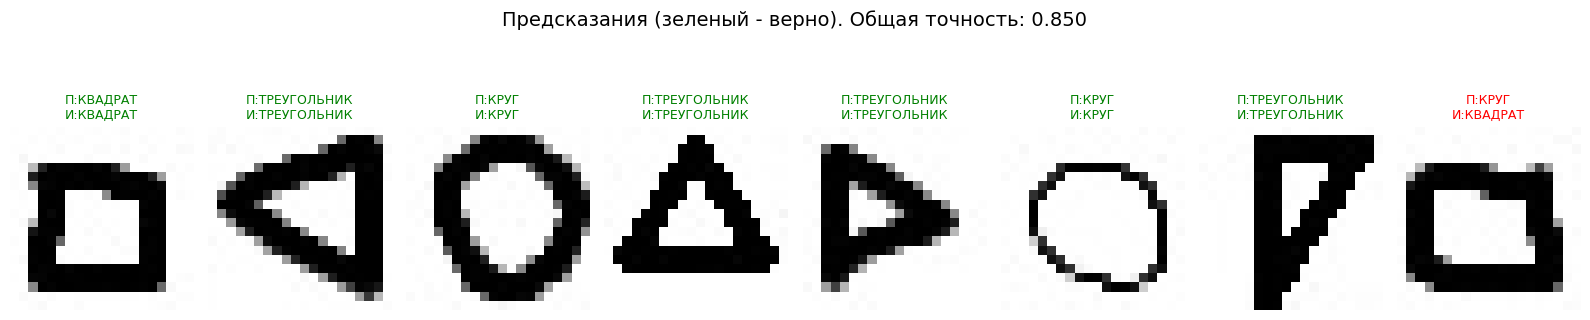

In [27]:
best_model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = best_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

final_acc = correct / total
print(f"Итоговая точность на валидации: {final_acc:.4f} ({final_acc*100:.1f}%)")

plt.figure(figsize=(16, 4))
indices = np.random.choice(len(x_val), 8, replace=False)

for i, idx in enumerate(indices):
    img = x_val[idx].cpu().numpy().reshape(20, 20)
    true = all_labels[idx] if idx < len(all_labels) else 0
    pred = all_preds[idx] if idx < len(all_preds) else 0

    plt.subplot(1, 8, i+1)
    plt.imshow(img, cmap='gray')
    color = 'green' if pred == true else 'red'
    plt.title(f'П:{class_names[pred]}\nИ:{class_names[true]}', color=color, fontsize=9)
    plt.axis('off')

plt.suptitle(f'Предсказания (зеленый - верно). Общая точность: {final_acc:.3f}', fontsize=14)
plt.tight_layout()
plt.show()